# Gut Microbiome CNN — IBD Classification
## Hyperparameter Grid Search + K-Fold Cross-Validation

**Pipeline (runs for all three taxa representations):**

| Phase | What happens |
|-------|-------------|
| **1 — Grid search** | 3-fold CV over 12 hyperparameter combos → selects best `lr`, `batch_size`, `conv_drop` |
| **2 — K-fold CV** | 5-fold CV with best params → `mean ± std` for thesis reporting |
| **3 — Final model** | Train on full training set → evaluate on held-out test set |
| **4 — Importance** | Permutation + Input×Gradient on metadata features *(metadata model only)* |

Runs in order: **image-only baseline** (Phases 1–3) then **metadata model** (Phases 1–4).  
Results written incrementally to `results/results_all_representations.xlsx` after each representation.

## 1 · Setup

In [2]:
%matplotlib inline

import sys
import os
sys.path.insert(0, '..')   # makes config.py and src/ importable from the project root

import gc
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# Project config (all constants in one place)
from config import (
    BASE_SEED, IMG_SHAPE, METADATA_PATH, RESULTS_XLSX, VIZ_DIR,
    REPRESENTATIONS, META_FEATURE_NAMES,
)

# Source modules
from src.pipeline    import run_grid_search, run_kfold_cv, run_final_model_image, run_final_model_meta
from src.importance  import run_importance_analysis
from src.utils       import load_representation, save_rep_to_excel
import src.visualization as viz

np.random.seed(BASE_SEED)
tf.random.set_seed(BASE_SEED)
print(f"TF  : {tf.__version__}")
print(f"GPU : {tf.config.list_physical_devices('GPU')}")

TF  : 2.16.2
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2 · Load Data

In [3]:
# Metadata is shared across all metadata model runs (loaded once here)
meta_npz = np.load(METADATA_PATH, allow_pickle=True)
M_train  = meta_npz['X_meta_train']
M_test   = meta_npz['X_meta_test']

print(f"Metadata   train: {M_train.shape}   test: {M_test.shape}")
print(f"Image shape     : {IMG_SHAPE}")
print(f"Representations : {[r[0] for r in REPRESENTATIONS]}")

Metadata   train: (6549, 20)   test: (1638, 20)
Image shape     : (78, 78, 1)
Representations : ['binary', 'normalized', 'log']


## 3 · Image-only Baseline (Phases 1 → 2 → 3)

CNN trained on taxa images **without** any metadata.  
Used as the ablation baseline to isolate the contribution of metadata to predictive performance.


##############################################################
#  BINARY  —  image only
##############################################################
  Train: (6549, 78, 78, 1)  Test: (1638, 78, 78, 1)  IBD train: 1501/6549 (22.9%)

  Phase 1 — Grid Search  [binary  |  image only]
  12 combos × 3 folds = 36 trains
  Combo  1/12 | Fold 1/3 | lr=1e-03  bs=32  cd=0.25 -> AUC=0.5615
  Combo  1/12 | Fold 2/3 | lr=1e-03  bs=32  cd=0.25 -> AUC=0.5980
  Combo  1/12 | Fold 3/3 | lr=1e-03  bs=32  cd=0.25 -> AUC=0.5607
  Combo  2/12 | Fold 1/3 | lr=1e-03  bs=64  cd=0.25 -> AUC=0.5768
  Combo  2/12 | Fold 2/3 | lr=1e-03  bs=64  cd=0.25 -> AUC=0.5863
  Combo  2/12 | Fold 3/3 | lr=1e-03  bs=64  cd=0.25 -> AUC=0.5635
  Combo  3/12 | Fold 1/3 | lr=1e-04  bs=32  cd=0.25 -> AUC=0.5803
  Combo  3/12 | Fold 2/3 | lr=1e-04  bs=32  cd=0.25 -> AUC=0.5939
  Combo  3/12 | Fold 3/3 | lr=1e-04  bs=32  cd=0.25 -> AUC=0.5429
  Combo  4/12 | Fold 1/3 | lr=1e-04  bs=64  cd=0.25 -> AUC=0.5741
  Combo  4/12 | Fold 2

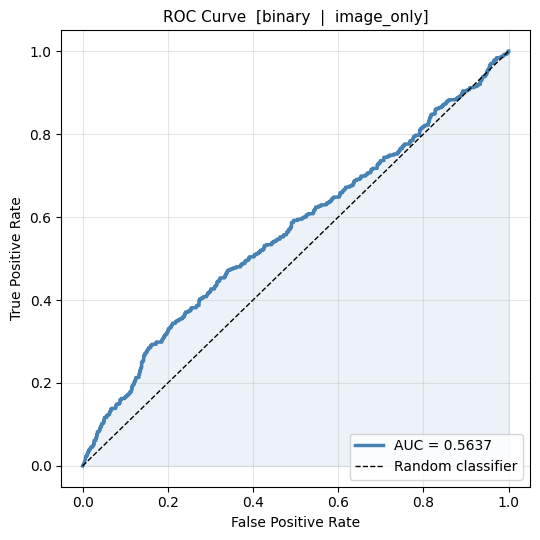

Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/visualizations/roc_binary_image_only.png


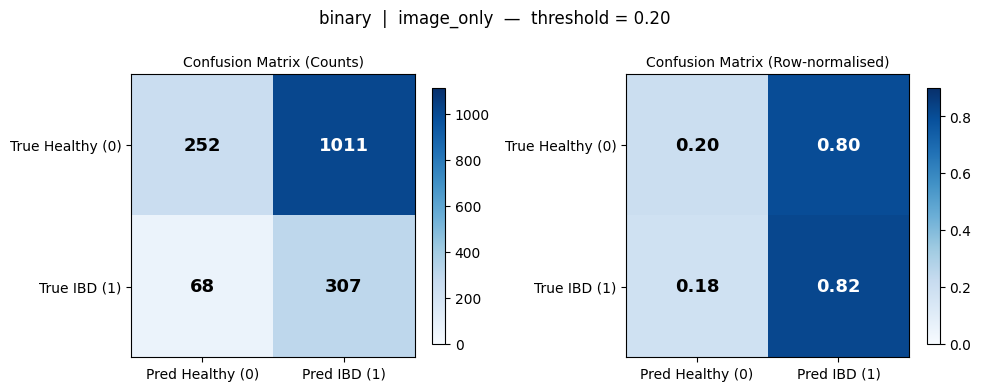

Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/visualizations/confusion_binary_image_only.png

##############################################################
#  NORMALIZED  —  image only
##############################################################
  Train: (6549, 78, 78, 1)  Test: (1638, 78, 78, 1)  IBD train: 1501/6549 (22.9%)

  Phase 1 — Grid Search  [normalized  |  image only]
  12 combos × 3 folds = 36 trains
  Combo  1/12 | Fold 1/3 | lr=1e-03  bs=32  cd=0.25 -> AUC=0.5647
  Combo  1/12 | Fold 2/3 | lr=1e-03  bs=32  cd=0.25 -> AUC=0.5758
  Combo  1/12 | Fold 3/3 | lr=1e-03  bs=32  cd=0.25 -> AUC=0.5641
  Combo  2/12 | Fold 1/3 | lr=1e-03  bs=64  cd=0.25 -> AUC=0.5892
  Combo  2/12 | Fold 2/3 | lr=1e-03  bs=64  cd=0.25 -> AUC=0.5817
  Combo  2/12 | Fold 3/3 | lr=1e-03  bs=64  cd=0.25 -> AUC=0.5468
  Combo  3/12 | Fold 1/3 | lr=1e-04  bs=32  cd=0.25 -> AUC=0.5787
  Combo  3/12 | Fold 2/3 | lr=1e

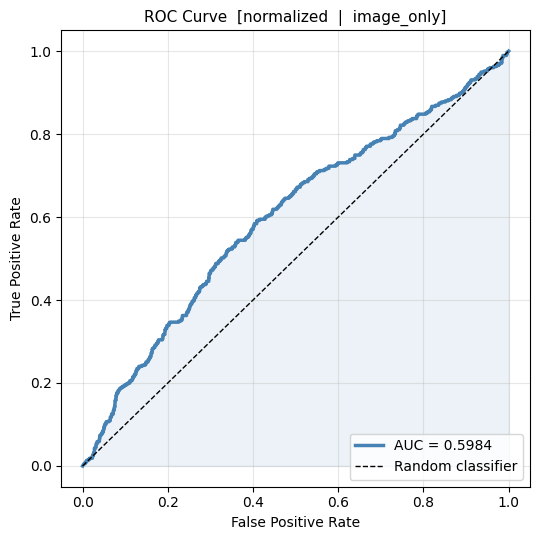

Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/visualizations/roc_normalized_image_only.png


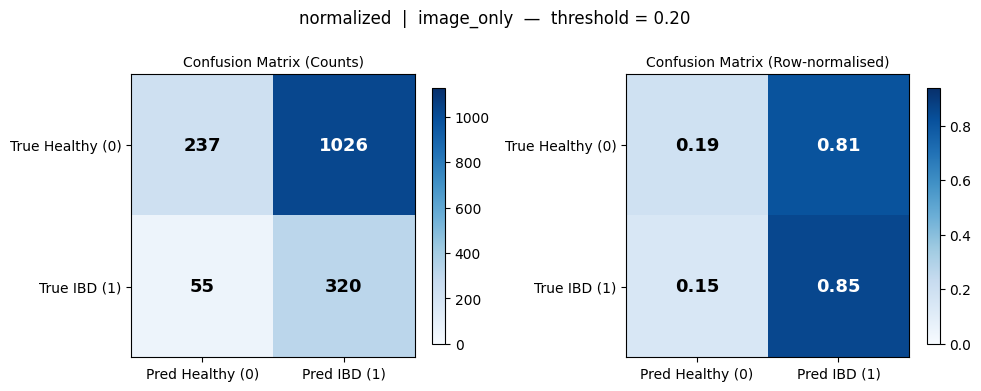

Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/visualizations/confusion_normalized_image_only.png

##############################################################
#  LOG  —  image only
##############################################################
  Train: (6549, 78, 78, 1)  Test: (1638, 78, 78, 1)  IBD train: 1501/6549 (22.9%)

  Phase 1 — Grid Search  [log  |  image only]
  12 combos × 3 folds = 36 trains
  Combo  1/12 | Fold 1/3 | lr=1e-03  bs=32  cd=0.25 -> AUC=0.5912
  Combo  1/12 | Fold 2/3 | lr=1e-03  bs=32  cd=0.25 -> AUC=0.5667
  Combo  1/12 | Fold 3/3 | lr=1e-03  bs=32  cd=0.25 -> AUC=0.5579
  Combo  2/12 | Fold 1/3 | lr=1e-03  bs=64  cd=0.25 -> AUC=0.5970
  Combo  2/12 | Fold 2/3 | lr=1e-03  bs=64  cd=0.25 -> AUC=0.5719
  Combo  2/12 | Fold 3/3 | lr=1e-03  bs=64  cd=0.25 -> AUC=0.5629
  Combo  3/12 | Fold 1/3 | lr=1e-04  bs=32  cd=0.25 -> AUC=0.5993
  Combo  3/12 | Fold 2/3 | lr=1e-04  bs=32

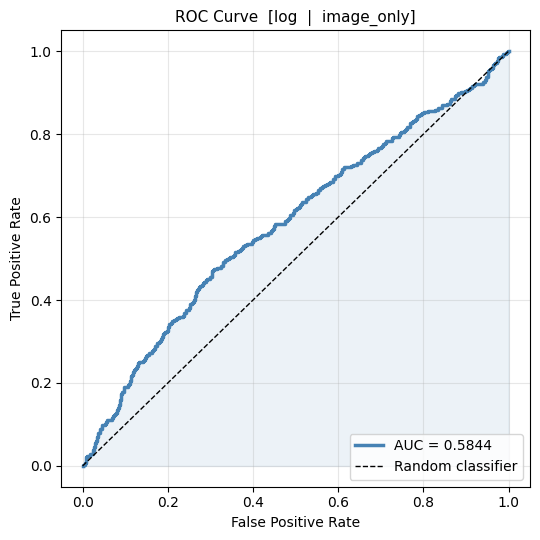

Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/visualizations/roc_log_image_only.png


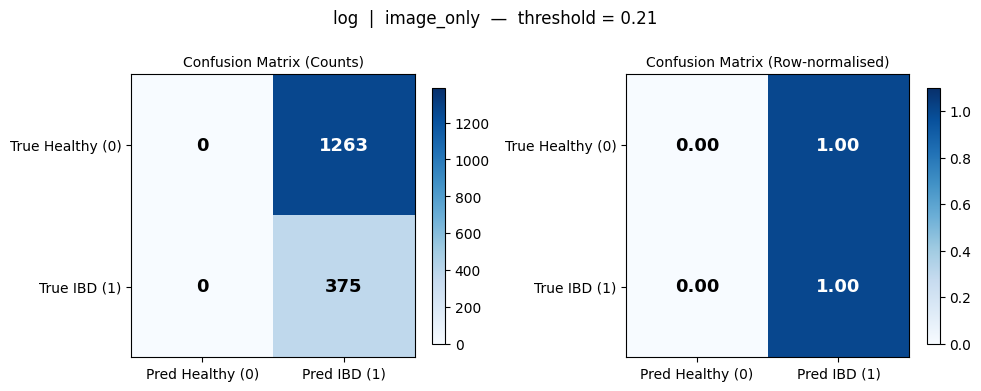

Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/visualizations/confusion_log_image_only.png

Image-only complete.  Results in /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/results_all_representations.xlsx


: 

In [ ]:
# Add representation names to skip (e.g. after a mid-run crash recovery).
# For a full clean run, leave this empty.
SKIP_REPS_IO = []

io_summary_rows     = []
all_cv_histories_io = {}

for rep_name, taxa_path, model_save_path in REPRESENTATIONS:
    if rep_name in SKIP_REPS_IO:
        print(f"  Skipping {rep_name} (listed in SKIP_REPS_IO)")
        continue

    io_save_path = model_save_path.replace('.keras', '_img_only.keras')
    print(f"\n{'#'*62}\n#  {rep_name.upper()}  —  image only\n{'#'*62}")

    X_train, X_test, y_train, y_test = load_representation(taxa_path)
    print(f"  Train: {X_train.shape}  Test: {X_test.shape}  "
          f"IBD train: {int(y_train.sum())}/{len(y_train)} ({100*y_train.mean():.1f}%)")

    # Phase 1: grid search (M_train=None → image-only mode)
    best_params, gs_df = run_grid_search(X_train, y_train, IMG_SHAPE, rep_name)

    # Phase 2: 5-fold CV (keep histories for learning curves)
    cv_metrics, cv_histories_io = run_kfold_cv(X_train, y_train, IMG_SHAPE, best_params, rep_name)

    # Phase 3: final model on test set
    test_metrics, test_probs_io = run_final_model_image(
        X_train, y_train, X_test, y_test, IMG_SHAPE, best_params, io_save_path, rep_name)

    # Incremental Excel save (crash-safe)
    save_rep_to_excel(f'{rep_name}_io', gs_df, cv_metrics, test_metrics)

    # Per-representation visuals (ROC + confusion matrix)
    viz.plot_roc_curve(test_probs_io, y_test, rep_name, VIZ_DIR, model_label='image_only')
    viz.plot_confusion_matrix(test_probs_io, test_metrics['threshold'], y_test,
                              rep_name, VIZ_DIR, model_label='image_only')
    all_cv_histories_io[rep_name] = cv_histories_io

    # Collect for summary
    aucs = [m['auc']    for m in cv_metrics]
    f1s  = [m['f1']     for m in cv_metrics]
    recs = [m['recall'] for m in cv_metrics]
    io_summary_rows.append({
        'representation' : rep_name,
        'model'          : 'image_only',
        'best_lr'        : best_params['lr'],
        'best_batch_size': best_params['batch_size'],
        'best_conv_drop' : best_params['conv_drop'],
        'cv_auc_mean'    : np.mean(aucs),  'cv_auc_std'    : np.std(aucs),
        'cv_f1_mean'     : np.mean(f1s),   'cv_f1_std'     : np.std(f1s),
        'cv_recall_mean' : np.mean(recs),  'cv_recall_std' : np.std(recs),
        'test_auc'       : test_metrics['auc'],
        'test_f1'        : test_metrics['f1'],
        'test_precision' : test_metrics['precision'],
        'test_recall'    : test_metrics['recall'],
        'test_tp'        : test_metrics['tp'],  'test_tn': test_metrics['tn'],
        'test_fp'        : test_metrics['fp'],  'test_fn': test_metrics['fn'],
    })

    tf.keras.backend.clear_session(); gc.collect()

io_summary_df = pd.DataFrame(io_summary_rows)
print(f"\nImage-only complete.  Results in {RESULTS_XLSX}")

## 4 · Metadata Model (Phases 1 → 2 → 3 → 4)

CNN trained on taxa images **fused with clinical metadata** (late fusion).  
Phase 4 runs permutation importance + Input×Gradient attribution on the final model.

**`SKIP_REPS_META`** — add representation names here to skip them (e.g. `['binary']` after a crash).  
For the full clean run, leave this list empty.

  Skipping binary (listed in SKIP_REPS_META)

##############################################################
#  NORMALIZED  —  metadata
##############################################################
  Train: (6549, 78, 78, 1)  Test: (1638, 78, 78, 1)  IBD train: 1501/6549 (22.9%)

  Phase 1 — Grid Search  [normalized  |  metadata]
  12 combos × 3 folds = 36 trains


2026-05-26 09:27:02.940459: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-05-26 09:27:02.940495: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-26 09:27:02.940502: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-26 09:27:02.940521: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-26 09:27:02.940535: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-05-26 09:27:04.139471: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  Combo  1/12 | Fold 1/3 | lr=1e-03  bs=32  cd=0.25 -> AUC=0.7583
  Combo  1/12 | Fold 2/3 | lr=1e-03  bs=32  cd=0.25 -> AUC=0.7497
  Combo  1/12 | Fold 3/3 | lr=1e-03  bs=32  cd=0.25 -> AUC=0.7439
  Combo  2/12 | Fold 1/3 | lr=1e-03  bs=64  cd=0.25 -> AUC=0.7441
  Combo  2/12 | Fold 2/3 | lr=1e-03  bs=64  cd=0.25 -> AUC=0.7504
  Combo  2/12 | Fold 3/3 | lr=1e-03  bs=64  cd=0.25 -> AUC=0.7618
  Combo  3/12 | Fold 1/3 | lr=1e-04  bs=32  cd=0.25 -> AUC=0.6690
  Combo  3/12 | Fold 2/3 | lr=1e-04  bs=32  cd=0.25 -> AUC=0.6369
  Combo  3/12 | Fold 3/3 | lr=1e-04  bs=32  cd=0.25 -> AUC=0.5965
  Combo  4/12 | Fold 1/3 | lr=1e-04  bs=64  cd=0.25 -> AUC=0.6194
  Combo  4/12 | Fold 2/3 | lr=1e-04  bs=64  cd=0.25 -> AUC=0.6032
  Combo  4/12 | Fold 3/3 | lr=1e-04  bs=64  cd=0.25 -> AUC=0.6011
  Combo  5/12 | Fold 1/3 | lr=1e-05  bs=32  cd=0.25 -> AUC=0.5477
  Combo  5/12 | Fold 2/3 | lr=1e-05  bs=32  cd=0.25 -> AUC=0.5851
  Combo  5/12 | Fold 3/3 | lr=1e-05  bs=32  cd=0.25 -> AUC=0.5139
  Combo  6

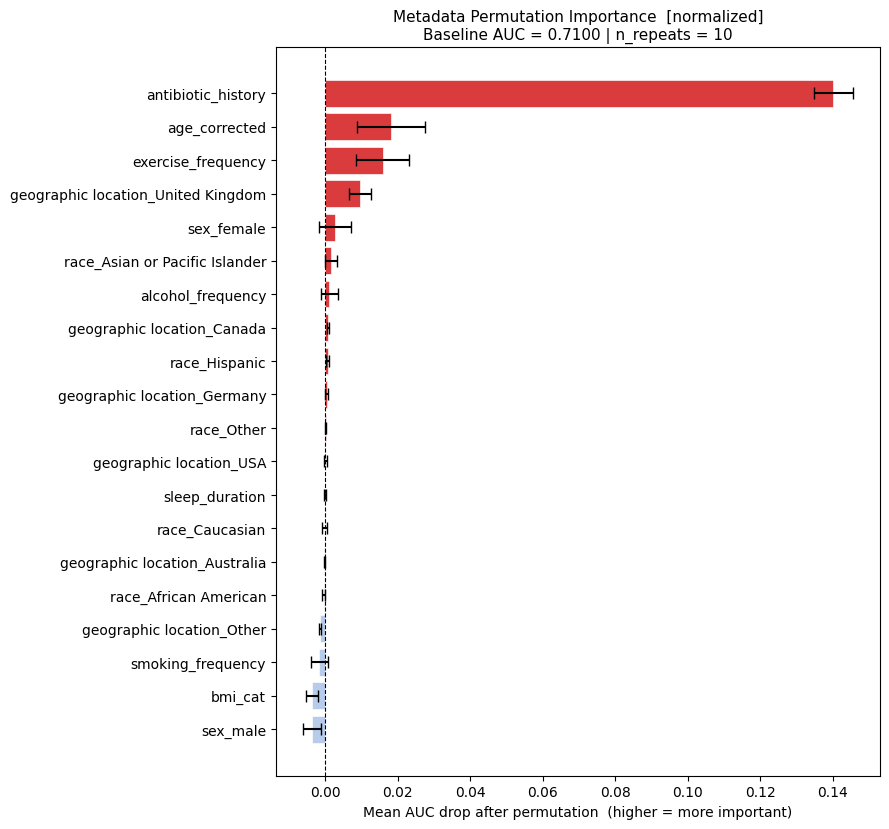

    Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/visualizations/perm_importance_normalized.png
  Gradient: single backward pass over 1638 test samples (batched)


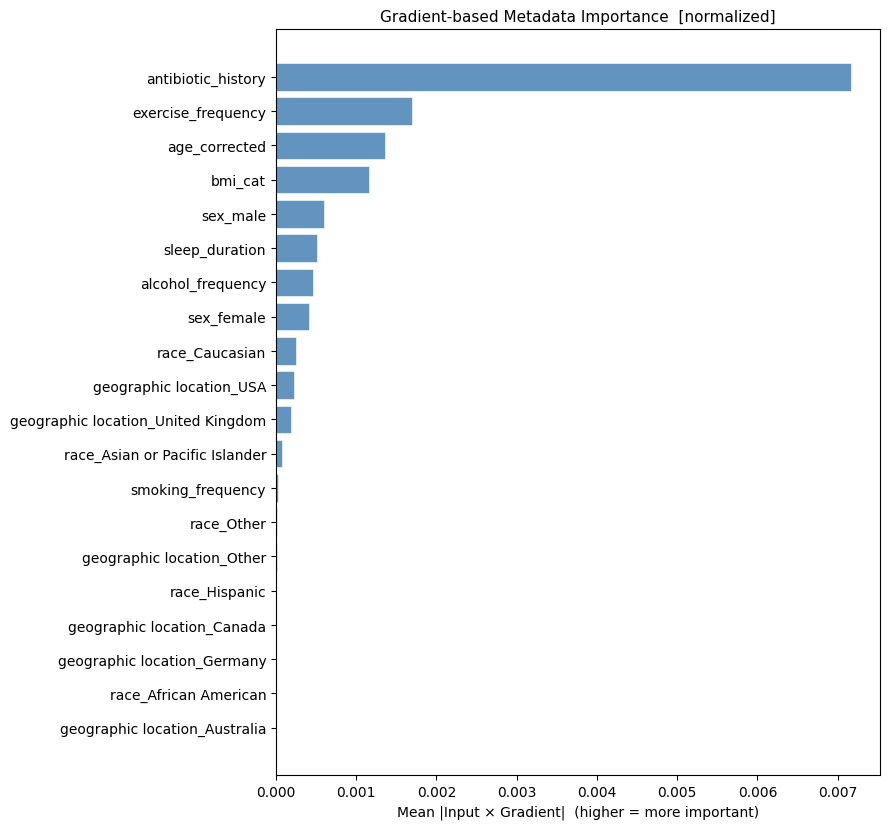

    Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/visualizations/grad_importance_normalized.png


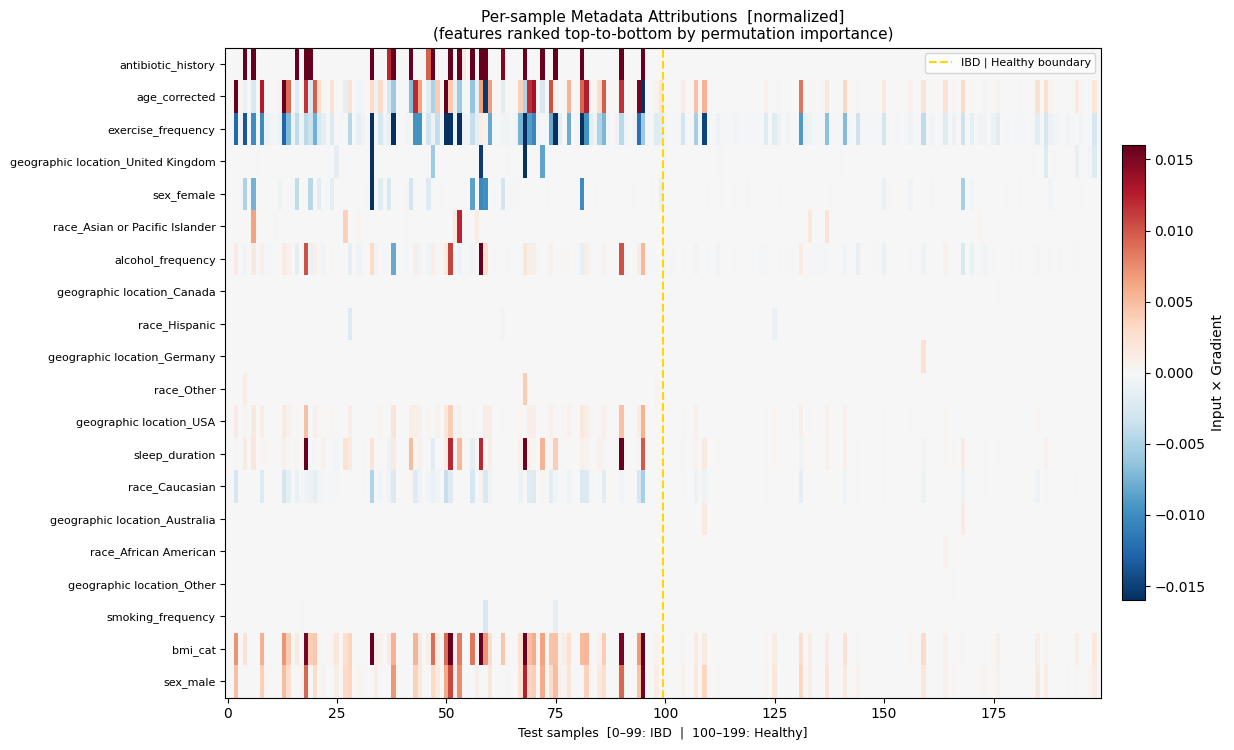

    Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/visualizations/attribution_heatmap_normalized.png


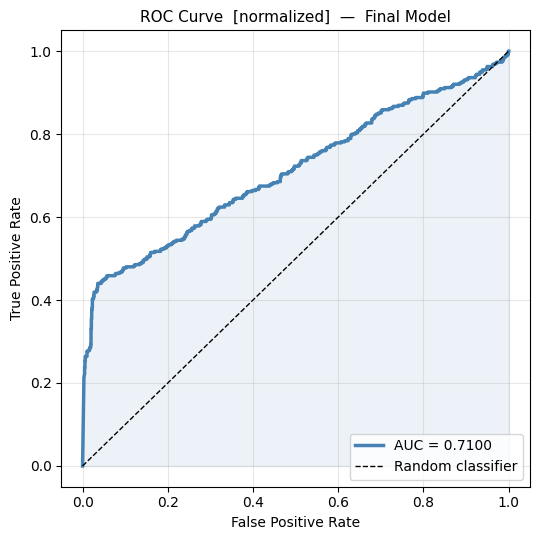

    Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/visualizations/roc_normalized.png


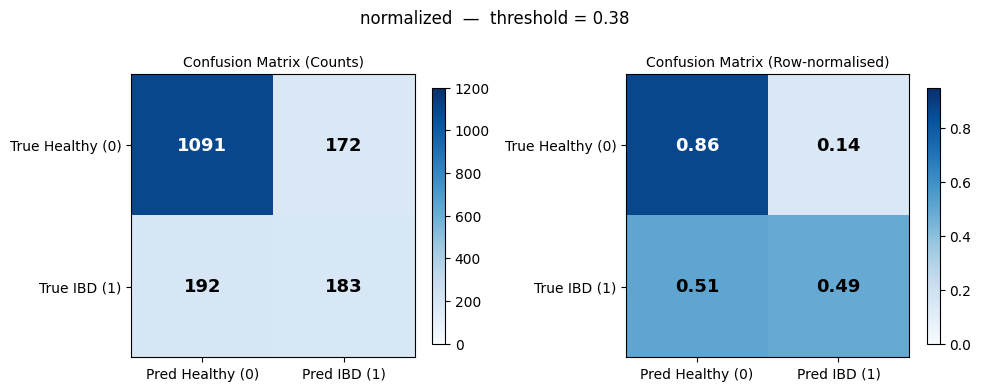

    Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/visualizations/confusion_normalized.png
  Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/results_all_representations.xlsx  (gs, cv, test, perm, grad  for normalized)
  Memory cleared after normalized

##############################################################
#  LOG  —  metadata
##############################################################
  Train: (6549, 78, 78, 1)  Test: (1638, 78, 78, 1)  IBD train: 1501/6549 (22.9%)

  Phase 1 — Grid Search  [log  |  metadata]
  12 combos × 3 folds = 36 trains
  Combo  1/12 | Fold 1/3 | lr=1e-03  bs=32  cd=0.25 -> AUC=0.7597
  Combo  1/12 | Fold 2/3 | lr=1e-03  bs=32  cd=0.25 -> AUC=0.7518
  Combo  1/12 | Fold 3/3 | lr=1e-03  bs=32  cd=0.25 -> AUC=0.7546
  Combo  2/12 | Fold 1/3 | lr=1e-03  bs=64  cd=0.25 -> AUC=0.7592
  Com

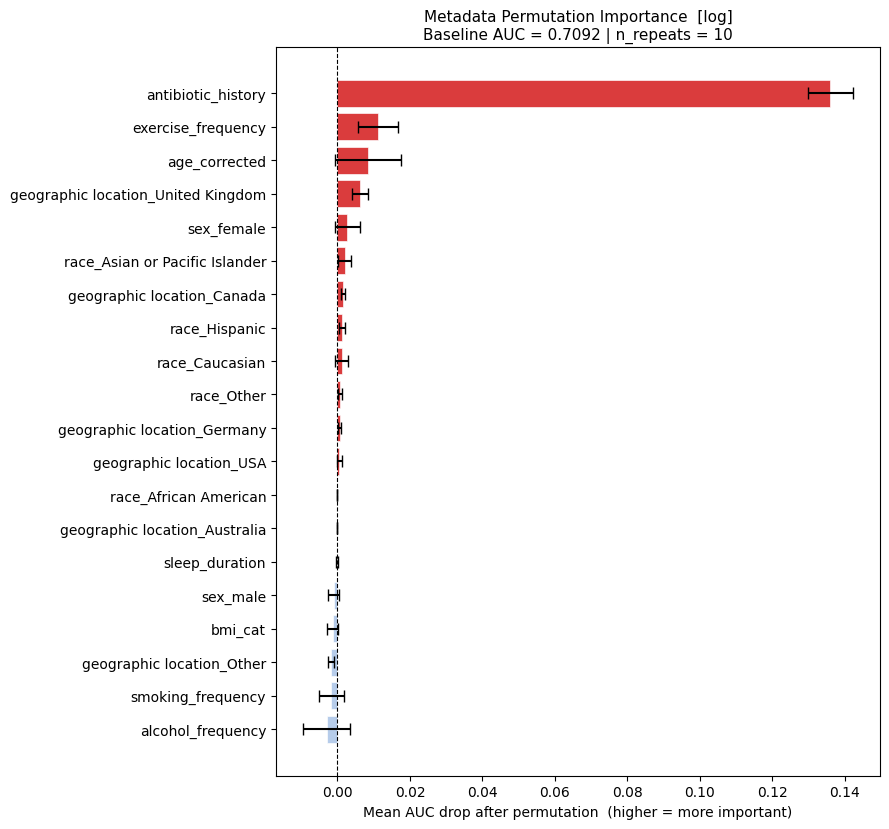

    Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/visualizations/perm_importance_log.png
  Gradient: single backward pass over 1638 test samples (batched)


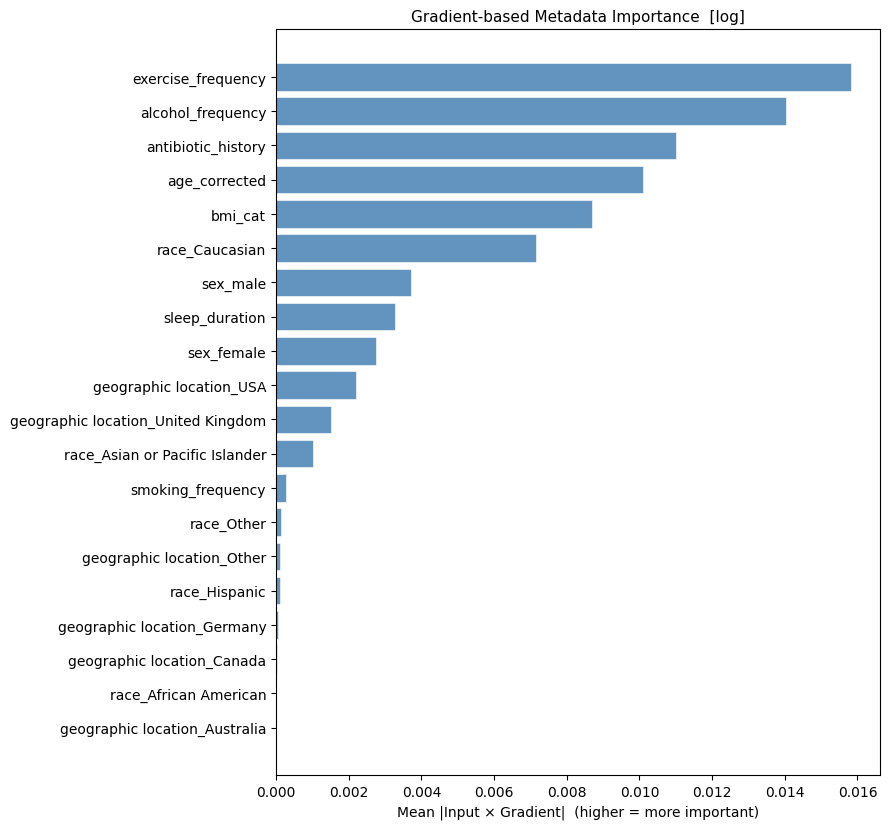

    Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/visualizations/grad_importance_log.png


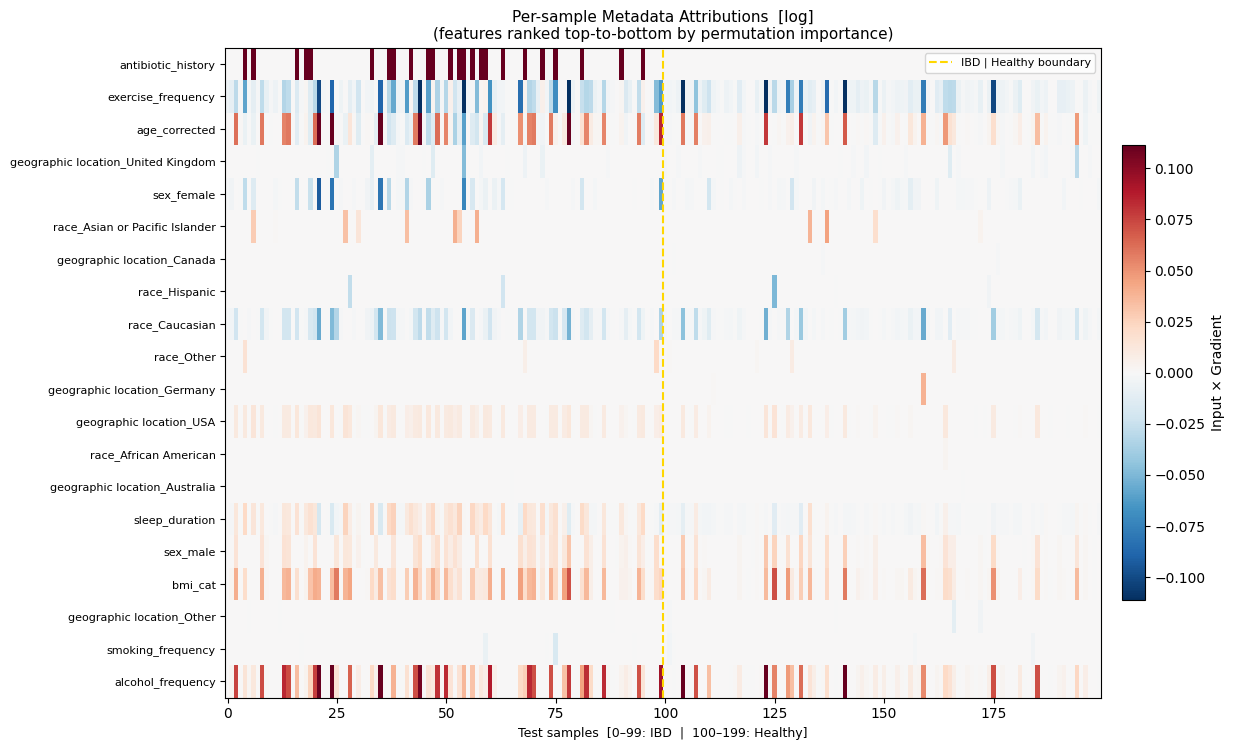

    Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/visualizations/attribution_heatmap_log.png


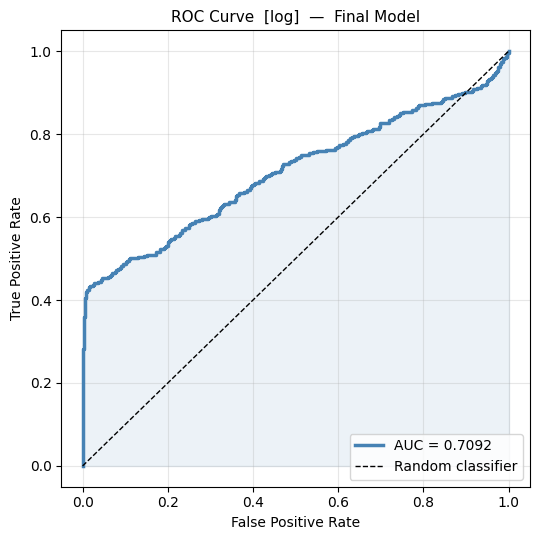

    Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/visualizations/roc_log.png


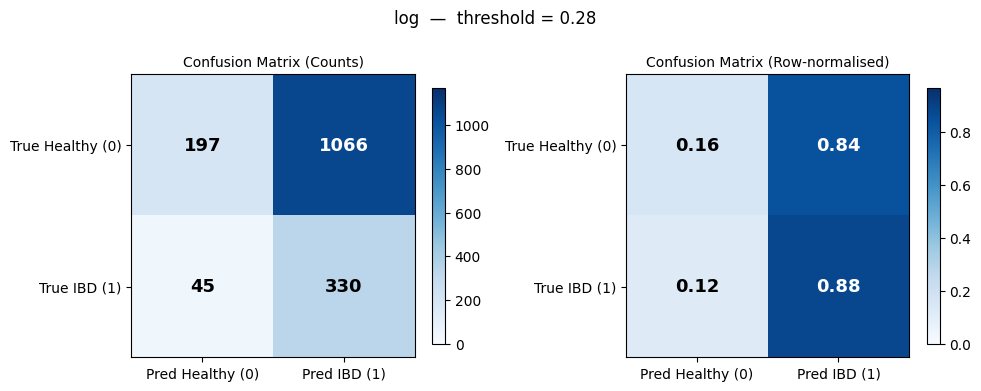

    Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/visualizations/confusion_log.png
  Saved -> /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/results_all_representations.xlsx  (gs, cv, test, perm, grad  for log)
  Memory cleared after log

Metadata model complete.  Results in /Users/macbook/Downloads/BCs Data Science and Society/Thesis/gut-microbiome-cnn-disease-classification/notebooks/../results/results_all_representations.xlsx


In [4]:
# Add representation names to skip (e.g. after a mid-run crash recovery).
# For a full clean run, leave this empty.
SKIP_REPS_META = ['binary'] # use 'binary', 'normalized', or 'log'

meta_summary_rows     = []
all_cv_histories_meta = {}
all_perm_imp_meta     = {}
all_grad_imp_meta     = {}

for rep_name, taxa_path, model_save_path in REPRESENTATIONS:
    if rep_name in SKIP_REPS_META:
        print(f"  Skipping {rep_name} (listed in SKIP_REPS_META)")
        continue
    print(f"\n{'#'*62}\n#  {rep_name.upper()}  —  metadata\n{'#'*62}")

    X_train, X_test, y_train, y_test = load_representation(taxa_path)
    print(f"  Train: {X_train.shape}  Test: {X_test.shape}  "
          f"IBD train: {int(y_train.sum())}/{len(y_train)} ({100*y_train.mean():.1f}%)")

    # Phase 1: grid search (M_train passed → metadata mode)
    best_params, gs_df = run_grid_search(
        X_train, y_train, IMG_SHAPE, rep_name, M_train=M_train)

    # Phase 2: 5-fold CV
    cv_metrics, cv_histories_meta = run_kfold_cv(
        X_train, y_train, IMG_SHAPE, best_params, rep_name, M_train=M_train)
    all_cv_histories_meta[rep_name] = cv_histories_meta

    # Phase 3: final model (returns model + scaler + probs needed for Phase 4)
    test_metrics, final_model_meta, final_scaler_meta, test_probs_meta = run_final_model_meta(
        X_train, M_train, y_train, X_test, M_test, y_test,
        IMG_SHAPE, best_params, model_save_path, rep_name)

    # Phase 4: feature importance (permutation + gradient)
    X_test_s_meta = final_scaler_meta.transform(
        X_test.reshape(len(X_test), -1)).reshape(X_test.shape)
    perm_df, mean_attr, _ = run_importance_analysis(
        final_model_meta, X_test_s_meta, M_test, y_test,
        test_probs_meta, test_metrics['threshold'], META_FEATURE_NAMES, rep_name, VIZ_DIR)
    all_perm_imp_meta[rep_name] = perm_df
    all_grad_imp_meta[rep_name] = mean_attr

    # Incremental Excel save (crash-safe; includes importance sheets)
    grad_df = (pd.DataFrame({'feature': META_FEATURE_NAMES, 'mean_attr': mean_attr})
               .sort_values('mean_attr', ascending=False))
    save_rep_to_excel(rep_name, gs_df, cv_metrics, test_metrics, perm_df, grad_df)

    # Collect for summary
    aucs = [m['auc']    for m in cv_metrics]
    f1s  = [m['f1']     for m in cv_metrics]
    recs = [m['recall'] for m in cv_metrics]
    meta_summary_rows.append({
        'representation' : rep_name,
        'best_lr'        : best_params['lr'],
        'best_batch_size': best_params['batch_size'],
        'best_conv_drop' : best_params['conv_drop'],
        'cv_auc_mean'    : np.mean(aucs),  'cv_auc_std'    : np.std(aucs),
        'cv_f1_mean'     : np.mean(f1s),   'cv_f1_std'     : np.std(f1s),
        'cv_recall_mean' : np.mean(recs),  'cv_recall_std' : np.std(recs),
        'test_auc'       : test_metrics['auc'],
        'test_f1'        : test_metrics['f1'],
        'test_precision' : test_metrics['precision'],
        'test_recall'    : test_metrics['recall'],
        'test_tp'        : test_metrics['tp'],  'test_tn': test_metrics['tn'],
        'test_fp'        : test_metrics['fp'],  'test_fn': test_metrics['fn'],
    })

    tf.keras.backend.clear_session(); gc.collect()
    print(f"  Memory cleared after {rep_name}")

meta_summary_df = pd.DataFrame(meta_summary_rows)
print(f"\nMetadata model complete.  Results in {RESULTS_XLSX}")